# Computational Social Science Project #3 

**Enter your Name:** Simon Cooper

*Semester:* Fall 2025

## 1. Introduction

### Load data 

In [1]:
#
# load libraries
# -----------

# Given libraries:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.preprocessing import LabelBinarizer

# Added libraries:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
import xgboost as xgb
from sklearn.metrics import make_scorer, accuracy_score, recall_score, precision_score, f1_score
from sklearn.model_selection import cross_validate
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

# There are a few warnings that will appear that will not affect your analysis. Run this code to ignore. 
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

# Make sure to import other libraries that will be necessary for training models!

In [2]:
#
# read in "Inspections Data 2011-2013" csv data
# -----------
chicago_inspections_2011_to_2013 = pd.read_csv("data/Chicago Inspections 2011-2013.csv", 
                                              low_memory=False)

#
# read in  "Inspections Data 2014_updated" csv data
# -----------
chicago_inspections_2014 = pd.read_csv("data/Chicago Inspections 2014_updated.csv",  # be sure to use the "updated" data here
                                      low_memory=False)


In [3]:
# look at the inspections data
chicago_inspections_2011_to_2013.head()

,Inspection_ID,Inspection_Date,DBA_Name,AKA_Name,License,Facility_Type,Risk,Address,City,State,Zip,Inspection_Type,Results,Latitude,Longitude,Location,Facility_Type_Clean,criticalCount,seriousCount,minorCount,pass_flag,fail_flag,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ID,LICENSE_ID,ACCOUNT_NUMBER,LEGAL_NAME,DOING_BUSINESS_AS_NAME,ADDRESS,CITY,STATE,ZIP_CODE,WARD,PRECINCT,WARD_PRECINCT,POLICE_DISTRICT,LICENSE_CODE,LICENSE_DESCRIPTION,BUSINESS_ACTIVITY_ID,BUSINESS_ACTIVITY,LICENSE_NUMBER,APPLICATION_TYPE,LICENSE_TERM_START_DATE,LICENSE_TERM_EXPIRATION_DATE,LICENSE_STATUS,LATITUDE,LONGITUDE,minDate,maxDate,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound
0,269961,2013-01-31,SEVEN STAR,SEVEN STAR,30790,Grocery Store,Risk 3 (Low),3352 N BROADWAY,CHICAGO,IL,60657.0,Canvass,Pass,41.943359,-87.644999,"(41.943359344775146, -87.64499875300952)",Other,0,0,2,1,0,0,0,0,0,2.0,1,30790-20110416,2081412.0,63759.0,VIRGINIA DELA ROSA,SEVEN STAR,3352 N BROADWAY 1,CHICAGO,IL,60657.0,44.0,33.0,44-33,19.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,30790.0,RENEW,2011-04-16,2013-04-15,AAI,41.943359,-87.644999,2002-02-16,2015-04-15,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0
1,507211,2011-10-18,PANERA BREAD,PANERA BREAD,1475890,Restaurant,Risk 1 (High),6059 N LINCOLN AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.991919,-87.709631,"(41.99191947239194, -87.70963133440333)",Restaurant,0,0,3,1,0,0,0,0,0,2.0,1,1475890-20110416,2081695.0,207283.0,"PANERA, LLC",PANERA BREAD,6059 N LINCOLN AVE C,CHICAGO,IL,60659.0,50.0,23.0,50-23,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1475890.0,RENEW,2011-04-16,2013-04-15,AAI,41.991919,-87.709631,2004-05-05,2019-04-15,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0
2,507212,2011-10-18,LITTLE QUIAPO RESTAURANT,LITTLE QUIAPO RESTAURANT,1740130,Restaurant,Risk 1 (High),6259 N MCCORMICK RD,CHICAGO,IL,60659.0,Canvass,Fail,41.995632,-87.712707,"(41.99563177556418, -87.71270678169132)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1740130-20110216,2070145.0,3107.0,ENELITA GARCIA,LITTLE QUIAPO RESTAURANT,6259 N MCCORMICK RD,CHICAGO,IL,60659.0,50.0,25.0,50-25,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1740130.0,RENEW,2011-02-16,2013-02-15,AAI,41.995632,-87.712707,2007-03-22,2017-02-15,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0
3,507216,2011-10-19,SERGIO'S TAQUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA,1447363,Restaurant,Risk 1 (High),3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,Canvass,Pass,41.982933,-87.710982,"(41.982933189164974, -87.71098225381141)",Restaurant,0,0,6,1,0,0,0,0,0,2.0,1,1447363-20110216,2071895.0,270993.0,SERGIO'S TAZUERIA PIZZA INC.,SERGIO'S TAQUERIA PIZZA INC.,3253 W BRYN MAWR AVE,CHICAGO,IL,60659.0,39.0,48.0,39-48,17.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1447363.0,RENEW,2011-02-16,2013-02-15,AAI,41.982933,-87.710982,2003-12-31,2019-02-15,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0
4,507219,2011-10-20,TARGET STORE # T-2079,TARGET,1679459,Restaurant,Risk 2 (Medium),2112 W PETERSON AVE,CHICAGO,IL,60659.0,Canvass,Fail,41.990729,-87.682979,"(41.99072921796059, -87.68297945359863)",Restaurant,0,2,6,0,1,0,0,0,0,2.0,1,1679459-20100216,2009972.0,15538.0,TARGET CORPORATION,TARGET STORE # T-2079,2112 W PETERSON AVE,CHICAGO,IL,60659.0,40.0,18.0,40-18,24.0,1006.0,Retail Food Establishment,775,Retail Sales of Perishable Foods,1679459.0,RENEW,

In [4]:
# list column names
chicago_inspections_2011_to_2013.columns

Index(['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License',
       'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip',
       'Inspection_Type', 'Results', 'Latitude', 'Longitude', 'Location',
       'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount',
       'pass_flag', 'fail_flag', 'pastFail', 'pastCritical', 'pastSerious',
       'pastMinor', 'timeSinceLast', 'firstRecord', 'ID', 'LICENSE_ID',
       'ACCOUNT_NUMBER', 'LEGAL_NAME', 'DOING_BUSINESS_AS_NAME', 'ADDRESS',
       'CITY', 'STATE', 'ZIP_CODE', 'WARD', 'PRECINCT', 'WARD_PRECINCT',
       'POLICE_DISTRICT', 'LICENSE_CODE', 'LICENSE_DESCRIPTION',
       'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY', 'LICENSE_NUMBER',
       'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE',
       'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE',
       'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection',
       'consumption_on_premises_incidental_activity', 'tobacco',
       'package_goods',

There are some other column names that I think I should drop, namely "POLICE_DISTRICT." Updating the next code chunk accordingly.

In [5]:
# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
chicago_inspections_2011_to_2013.drop(columns = ['AKA_Name', 
                                                 'License',
                                                 'Address',
                                                 'City',
                                                 'State',
                                                 'Zip',
                                                 'Latitude',
                                                 'Longitude',
                                                 'Location',
                                                 'ID',
                                                 'LICENSE_ID',
                                                 'LICENSE_TERM_START_DATE',
                                                 'LICENSE_TERM_EXPIRATION_DATE',
                                                 'LICENSE_STATUS',
                                                 'ACCOUNT_NUMBER',
                                                 'LEGAL_NAME',
                                                 'DOING_BUSINESS_AS_NAME',
                                                 'ADDRESS',
                                                 'CITY',
                                                 'STATE',
                                                 'ZIP_CODE',
                                                 'WARD',
                                                 'PRECINCT',
                                                 'POLICE_DISTRICT',
                                                 'LICENSE_CODE',
                                                 'BUSINESS_ACTIVITY_ID',
                                                 'BUSINESS_ACTIVITY',
                                                 'LICENSE_NUMBER',
                                                 'LATITUDE',
                                                 'LONGITUDE',
                                                 'pass_flag',
                                                 'fail_flag'],
                                     inplace = True)

# set index
chicago_inspections_2011_to_2013.set_index(['Inspection_ID', 'DBA_Name'], inplace = True)

In [6]:
# convert the inspection date to a datetime format
chicago_inspections_2011_to_2013['Inspection_Date'] = pd.to_datetime(chicago_inspections_2011_to_2013['Inspection_Date'])  

### Visualization

Let's visualize what inspections look like over time.

In [7]:
# visualize inspections over time
# -----------
chicago_inspections_2011_to_2013['Inspection_MonthYear'] = chicago_inspections_2011_to_2013['Inspection_Date'].dt.to_period('M')
counts_by_day = chicago_inspections_2011_to_2013.groupby('Inspection_MonthYear').count().rename(columns = {'Facility_Type': 'Count'})['Count'].reset_index()
counts_by_day.set_index(["Inspection_MonthYear"], inplace = True)
counts_by_day.plot(title = "Inspections by Month and Year") 

<Axes: title={'center': 'Inspections by Month and Year'}, xlabel='Inspection_MonthYear'>

Let's visualize what the distribution of results looks like.

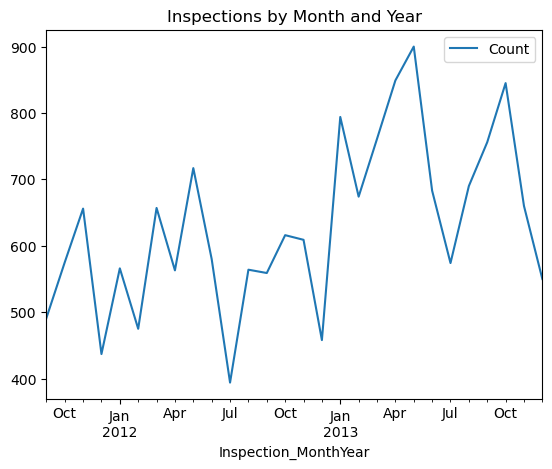

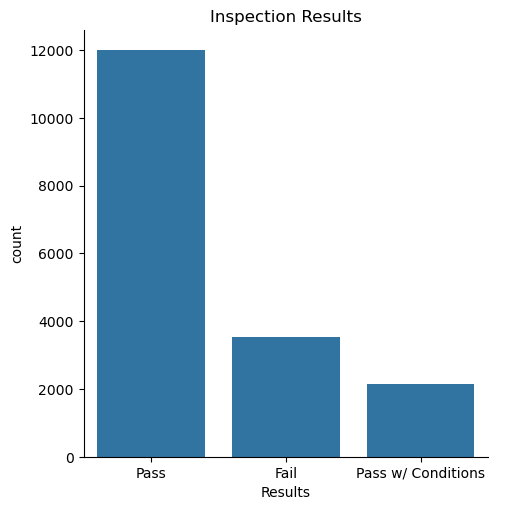

In [8]:
# view inspection results
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
           x = "Results",
           kind = "count")

plt.title("Inspection Results")
plt.show()

What if we separate results by facility type?

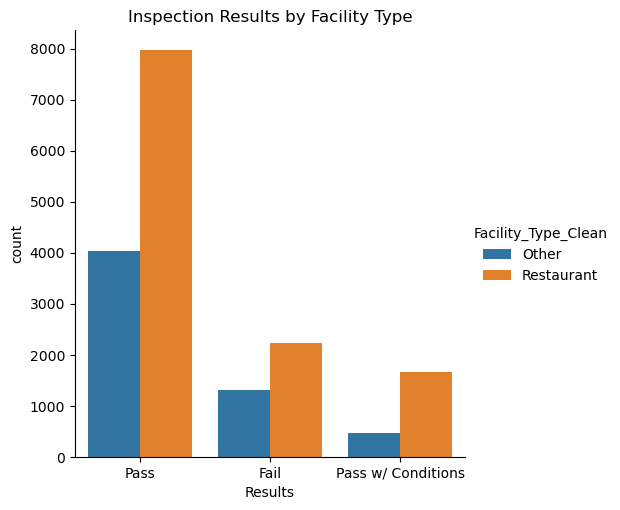

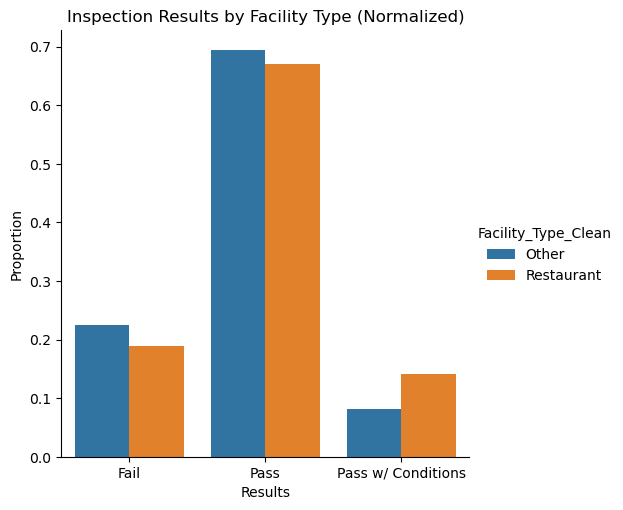

In [9]:
# view inspection results by facility type (restaurant or not)
# -----------
sns.catplot(data = chicago_inspections_2011_to_2013,
            x = "Results",
            kind = "count",
            hue = 'Facility_Type_Clean')

plt.title("Inspection Results by Facility Type")
plt.show();

# viewing inspection results by facility type as proportions/normalized to the number of facilities of that type.
# calculating proportions of results within each facility type.
proportions = chicago_inspections_2011_to_2013.groupby(['Facility_Type_Clean', 'Results']).size().unstack(fill_value=0)
proportions = proportions.div(proportions.sum(axis=1), axis=0)

# converting to long format for seaborn. 
proportions_long = proportions.reset_index().melt(id_vars='Facility_Type_Clean', 
                                                    var_name='Results', 
                                                    value_name='Proportion')
# plotting.
sns.catplot(data=proportions_long,
            x="Results",
            y="Proportion",
            kind="bar",
            hue='Facility_Type_Clean')
plt.title("Inspection Results by Facility Type (Normalized)")
plt.show()

Looking at the normalized inspection results by facility type, it's interesting to me that "other" facility types are more likely to "fail" or "pass" their inspections than "restaurant" facility types, but that they are less likely to "pass w/ conditions" compared to restaurants. 

## 2. Data Preprocessing and Cleaning

In [10]:
# drop datetime info
# -----------
chicago_inspections_2011_to_2013 = chicago_inspections_2011_to_2013.dropna().drop(['Inspection_Date',
                                                                                   'minDate',
                                                                                   'maxDate',
                                                                                   'Inspection_MonthYear'],
                                                                                  axis = 1)

In [11]:
# process target 
# -----------
y = chicago_inspections_2011_to_2013['Results']

# decide if you want to binarize the outcome variable 

# -----------
# comment out the following lines of code if you don't want to binarize the target variable
y = y.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y = lb_style.fit_transform(y)

# recode 0s and 1s so 1s are "Fail"
y = np.where(y == 1, 0 ,1)


# process features
# -----------

# create feature dataset
X = chicago_inspections_2011_to_2013.drop(columns = ['Results', 
                                                     'Facility_Type', 
                                                     'LICENSE_DESCRIPTION', 
                                                     'WARD_PRECINCT'])


# get dummies
X = pd.get_dummies(X)

In [12]:
# view feature datset
X.head()

,,criticalCount,seriousCount,minorCount,pastFail,pastCritical,pastSerious,pastMinor,timeSinceLast,firstRecord,ageAtInspection,consumption_on_premises_incidental_activity,tobacco,package_goods,outdoor_patio,public_place_of_amusement,limited_business_license,childrens_services_facility_license,tavern,regulated_business_license,filling_station,caterers_liquor_license,mobile_food_license,precipIntensity,temperatureMax,windSpeed,humidity,heat_burglary,heat_garbage,heat_sanitation,criticalFound,Risk_Risk 1 (High),Risk_Risk 2 (Medium),Risk_Risk 3 (Low),Inspection_Type_Canvass,Facility_Type_Clean_Other,Facility_Type_Clean_Restaurant,APPLICATION_TYPE_C_EXPA,APPLICATION_TYPE_C_LOC,APPLICATION_TYPE_ISSUE,APPLICATION_TYPE_RENEW
Inspection_ID,DBA_Name,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
269961,SEVEN STAR,0,0,2,0,0,0,0,2.0,1,10.964384,0,1,0,0,0,1,0,0,0,0,0,0,0.014587,53.496667,13.340000,0.900000,26.992376,12.768572,37.748787,0,False,False,True,True,True,False,False,False,False,True
507211,PANERA BREAD,0,0,3,0,0,0,0,2.0,1,7.457534,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,13.976557,12.895485,15.412267,0,True,False,False,True,False,True,False,False,False,True
507212,LITTLE QUIAPO RESTAURANT,0,2,6,0,0,0,0,2.0,1,4.578082,0,0,0,0,0,0,0,0,0,0,0,0,0.001907,59.046667,13.016667,0.550000,12.611239,8.004220,8.320330,0,True,False,False,True,False,True,False,False,False,True
507216,SERGIO'S TAQUERIA PIZZA INC.,0,0,6,0,0,0,0,2.0,1,7.805479,0,0,0,0,0,0,0,0,0,0,0,0,0.002737,56.153333,10.863333,0.616667,35.906383,26.238645,38.186618,0,True,False,False,True,False,True,False,False,False,True
507219,TARGET STORE # T-2079,0,2,6,0,0,0,0,2.0,1,5.290411,0,0,1,0,0,1,0,0,0,0,0,0,0.009987,52.730000,16.266667,0.690000,9.530785,3.401567,2.126788,0,False,True,False,True,False,True,False,False,False,True


## 3. Fit Models

Now choose 3 different machine learning techniques and apply them below. Choose from one of the algorithms we have used in lab (e.g., logistic regression, random forests, `AdaBoost()`, `xgboost()`, `VotingClassifer()`, or `BART`). 

Detail the basic logic and assumptions underlying each model, its pros/cons, and why it is a plausible choice for this problem. Also, be sure to do the following:

1. Import the appropriate library from sklearn
2. Set up a hyperparameter grid (check out our previous labs to see how to do this)
3. Find the best hyperparameters, and then fit your model (using either train/validation splits or cross-validation)

### Model 1: Logistic Regression.

Basic logic and assumptions AND pros: logistic regression predicts the probability that our response belongs in the category of pass or fail. It's easy to implement and interpret, which is helpful for a first model among three.  
Cons: model parameters are unstable when there is substantial separation among the classes, which could be a problem here if, for example, failing a health inspection in the past very accurately predicts failing a health inspection in the future.
Why plausible choice for this problem: I think it's good to start with an easy to implement, interpret and explain model before moving to more complex models. Logistic regression does not work well for small sample sizes, but I think we have enough observations here that that won't be a problem.

In [13]:

# setting up hyperparameter grid.
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'], 
    'solver': ['liblinear'],
    'max_iter': [1000]
}

# creating logistic regression model.
logit_reg = LogisticRegression(random_state=42)

# setting up GridSearchCV with cross-validation.
grid_search = GridSearchCV(
    estimator=logit_reg,
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',  # or 'roc_auc', 'f1', etc.
    n_jobs=-1,
    verbose=1
)

# fitting the model to find the best hyperparameters.
grid_search.fit(X, y.ravel())

# identifying the best model.
best_logit_model = grid_search.best_estimator_

# printing best hyperparameters.
print("best hyperparameters:", grid_search.best_params_)
print("best cv score:", grid_search.best_score_)


Fitting 5 folds for each of 12 candidates, totalling 60 fits
best hyperparameters: {'C': 1, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'liblinear'}
best cv score: 0.9216084412309271


###  Model 2: Random Forest.

Basic logic and assumptions AND pros: random forest is an ensemble method that combines many decorrelated decision trees. In contrast to traditional bagging, random forest decorrelates the decision trees by restricting the number of predictors that can be used at each split. Each split draws on its own random subset of the available predictors. Random forest requires minimal assumptions and provides good measures of variable importance.  
Cons: not as easily interpretable as some other methods (e.g., logistic regression) and it can be computationally intensive.  
Why plausible choice for this problem: Because random forest is good at classification (e.g., avoids overfitting, relies on minimal assumptions) and easy to interpret, I think it's good for policy situations like this one. Given that we're using three models for this project, I think random forest is a good intermediate model between logistic regression (which is easier to implement and interpret but less powerful) and XGBoost, my next model.

In [14]:

# setting up hyperparameter grid.
# note: I would've liked to include more options in my hyperparameter grid, but just for computational efficiency, 
# I tried to keep the number of folds relatively low.
param_grid = {
    'n_estimators': [100, 200],  
    'max_depth': [10, 20, None],  
    'min_samples_split': [2, 5, 10],  
    'min_samples_leaf': [1, 4],  
    'max_features': ['sqrt', 'log2'],  
    'bootstrap': [True]  
}

# creating random forest classifier.
rf_classifier = RandomForestClassifier(random_state=42)

# setting up GridSearchCV with cross-validation.
grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# fitting the model to find the best hyperparameters.
grid_search.fit(X, y.ravel())

# identifying the best model.
best_rf_model = grid_search.best_estimator_

# printing best hyperparameters.
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best hyperparameters: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Best cross-validation score: 0.9254899817762159


### Model 3: XGBoost.

Basic logic and assumptions AND pros: in contrast to random forest and other bagging approaches, XGBoost is a boosting approach - it moves sequentially and only uses the original data. XGBoost is computationally efficient, avoids overfitting, and handles missing values well.  
Cons: XGBoost is relatively complex, making it harder to interpret and tune.  
Why plausible choice for this problem: XGBoost often outperforms other classification methods (including logistic regression and random forest) while also being computationally efficient. I think it's worth trying in case it performs much better than the random forest. That said, if all three models perform roughly the same, I think I'd choose to present the logistic regression method because of its straightforward interpretation.   

In [15]:

# setting up hyperparameter grid.
# note: (again) I would've liked to include more options in my hyperparameter grid, but just for computational efficiency, 
# I tried to keep the number of folds relatively low.
param_grid = {
    'n_estimators': [100, 200], 
    'max_depth': [3, 7],
    'learning_rate': [0.01, 0.1], 
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'min_child_weight': [1, 3]
}

# creating XGBoost classifier.
xgb_classifier = xgb.XGBClassifier(random_state=42)

# setting up GridSearchCV with cross-validation.
grid_search = GridSearchCV(
    estimator=xgb_classifier,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# fitting the model to find the best hyperparameters.
grid_search.fit(X, y.ravel())

# identifying the best model.
best_xgb_model = grid_search.best_estimator_

# printing best hyperparameters.
print("Best hyperparameters:", grid_search.best_params_)
print("Best cross-validation score:", grid_search.best_score_)



Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best hyperparameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}
Best cross-validation score: 0.9239628189465827


### Validation Metrics

Be sure to explain which of these metrics you would want to prioritize when conducting predictive auditing in this context and why.

**Hint**: Try writing a for loop to use [`cross_val_score()`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html) to check for accuracy, precision, recall and f1 across all of your models.

Note: I decided to use cross_validate() instead because I thought it would be simpler. 

Of the four metrics, I think I would prioritize F1. Recall is most important for identifying the largest proportion of restaurants that are most likely to fail health inspections. Paying attention to precision would help us avoid incorrectly identifying non-problematic restaurants as problematic. F1 the is mean of these two measures, making it a good choice for balancing between catching concerning restaurants (recall) and avoiding wasting resources on clean restaurants (precision). Looking at these validation metrics, I think the random forest model is the best choice because it has the highest F1 (and the highest recall).

In [16]:

# puting models together.
models = {
    'Logistic Regression': best_logit_model,
    'Random Forest': best_rf_model,
    'XGBoost': best_xgb_model
}

# defining scoring metrics.
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'recall': make_scorer(recall_score),
    'precision': make_scorer(precision_score),
    'f1': make_scorer(f1_score)
}

# looping through each model, performing cross-validation.
for model_name, model in models.items():
    print(f"\n{model_name}:")
    print("-" * 40)
    
    cv_results = cross_validate(model,
                                X,
                                y.ravel(),
                                cv=5,
                                scoring=scoring)
    
    # printing the results for each metric
    for metric in ['test_accuracy', 'test_recall', 'test_precision', 'test_f1']:
        scores = cv_results[metric]
        print(f"  {metric[5:]}: {scores.mean():.3f} (+/- {scores.std():.3f})")
        


Logistic Regression:
----------------------------------------
  accuracy: 0.922 (+/- 0.003)
  recall: 0.839 (+/- 0.041)
  precision: 0.786 (+/- 0.027)
  f1: 0.810 (+/- 0.008)

Random Forest:
----------------------------------------
  accuracy: 0.925 (+/- 0.008)
  recall: 0.906 (+/- 0.027)
  precision: 0.766 (+/- 0.028)
  f1: 0.830 (+/- 0.016)

XGBoost:
----------------------------------------
  accuracy: 0.924 (+/- 0.006)
  recall: 0.895 (+/- 0.025)
  precision: 0.766 (+/- 0.025)
  f1: 0.825 (+/- 0.013)


## 4. Policy Simulation

### Interpretable Machine Learning

Use tools like coefficient plots or feature importance plots to investigate your models. Which features contribute to your predictions? Are there any additional features you wish you could incorporate that you don't have available in this analysis?

**Hint**: Use tools like feature importance plots and coefficient plots.

Looking at these coefficient and feature 

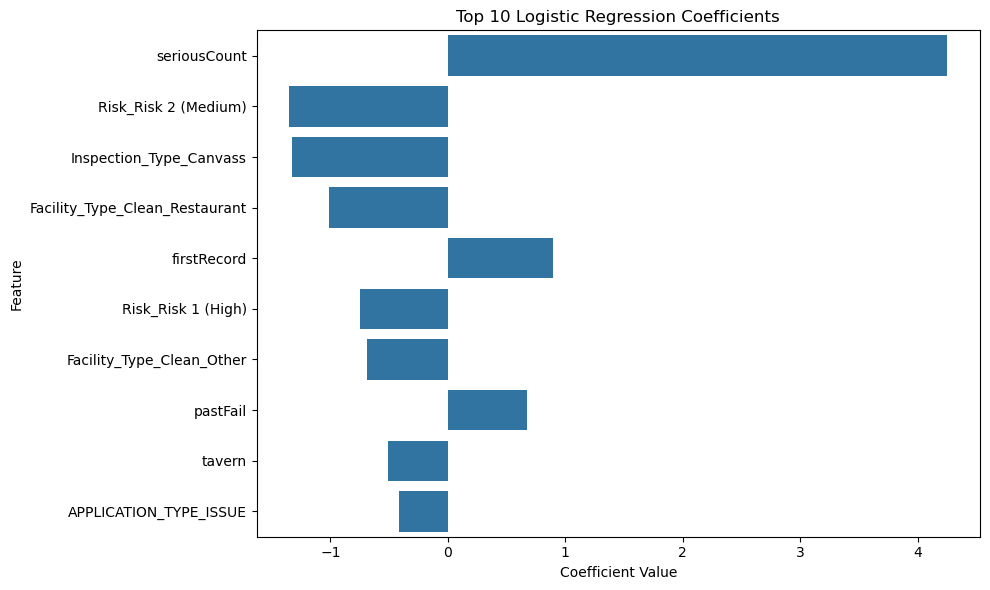

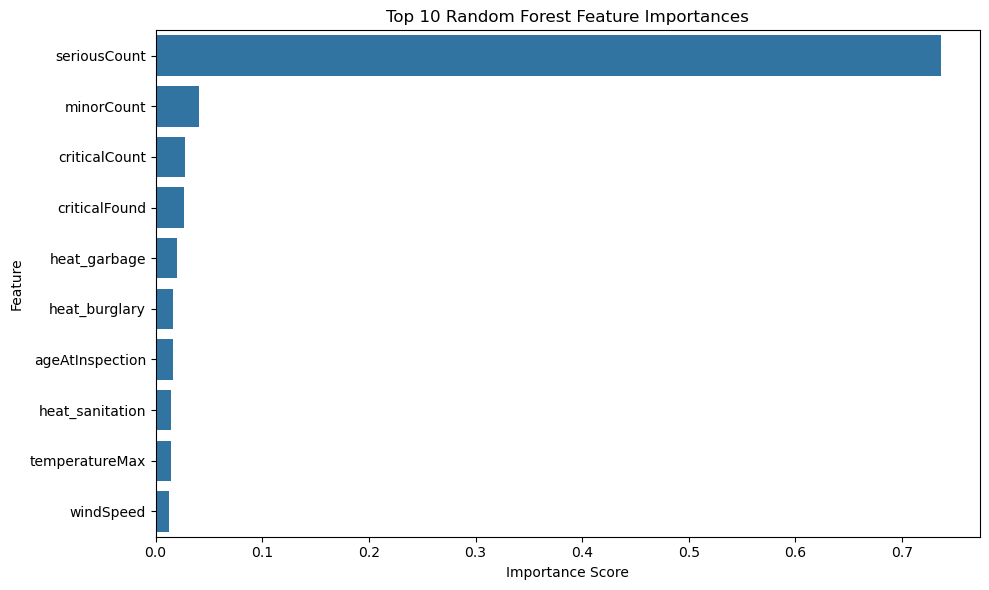

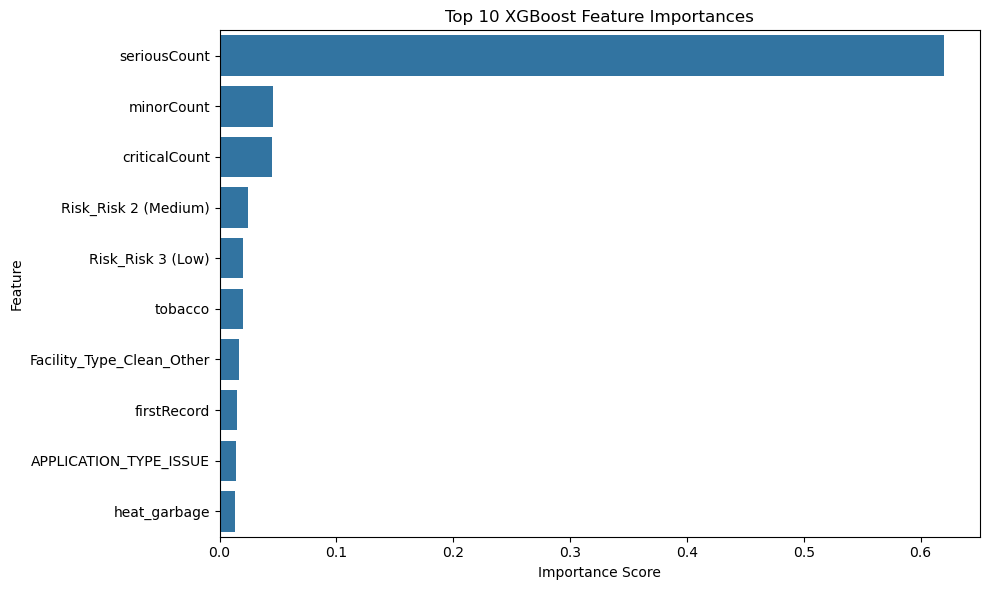

In [17]:

# logistic regression.

# extracting best model coefficients. 
logit_data = pd.concat([
    pd.DataFrame(X.columns),
    pd.DataFrame(np.transpose(best_logit_model.coef_))
], axis=1)

logit_data.columns = ['Feature', 'Coefficient']
logit_data['abs_coef'] = abs(logit_data['Coefficient'])

# plotting top 10 features by absolute coefficient value.
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Coefficient", 
    y="Feature", 
    data=logit_data.nlargest(10, 'abs_coef')
).set_title("Top 10 Logistic Regression Coefficients")
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

# random forest.

# extracting most important features. 
rf_importance_data = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf_model.feature_importances_
})

# sorting by importance.
rf_importance_data = rf_importance_data.sort_values('Importance', ascending=False)

# plotting top 10 most important features.
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance", 
    y="Feature", 
    data=rf_importance_data.head(10)
).set_title("Top 10 Random Forest Feature Importances")
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# XGBoost.

# extracting most important features. 
xgb_importance_data = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_xgb_model.feature_importances_
})

# sorting by importance.
xgb_importance_data = xgb_importance_data.sort_values('Importance', ascending=False)

# identifying top 10 features. 
xgb_top10 = xgb_importance_data.head(10)

# plotting top 10 most important features.
plt.figure(figsize=(10, 6))
sns.barplot(
    x="Importance", 
    y="Feature", 
    data=xgb_top10
).set_title("Top 10 XGBoost Feature Importances")
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()


### Prioritize Audits

**Hint**: Look up the [`.predict()`](https://www.kite.com/python/docs/sklearn.linear_model.SGDRegressor.predict), [`.predict_proba()`](https://www.kite.com/python/docs/sklearn.linear_model.LogisticRegression.predict_proba), and [`.sample()`](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.sample.html) methods. Then: 
1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities. 
2. Order your audits by their probability of detecting a "Fail" score
3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset
4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

In [18]:
#
# 1. Choose one of your models (or train a new simplified model or ensemble!) to predict outcomes and probabilities.
predictions = best_rf_model.predict(X)
probabilities = best_rf_model.predict_proba(X)
prob_fail = probabilities[:, 1]


In [19]:
#
# 2. Order your audits by their probability of detecting a "Fail" score

# creating dataframe with the predictions and probabilities.
audits_df = pd.DataFrame({
    'prob_fail': prob_fail,
    'predicted_outcome': predictions
})

# adding the index to keep track of original observation numbers.
audits_df['original_index'] = audits_df.index

# ordering by probability of fail (highest to lowest).
audits_ordered = audits_df.sort_values('prob_fail', ascending=False).reset_index(drop=True)


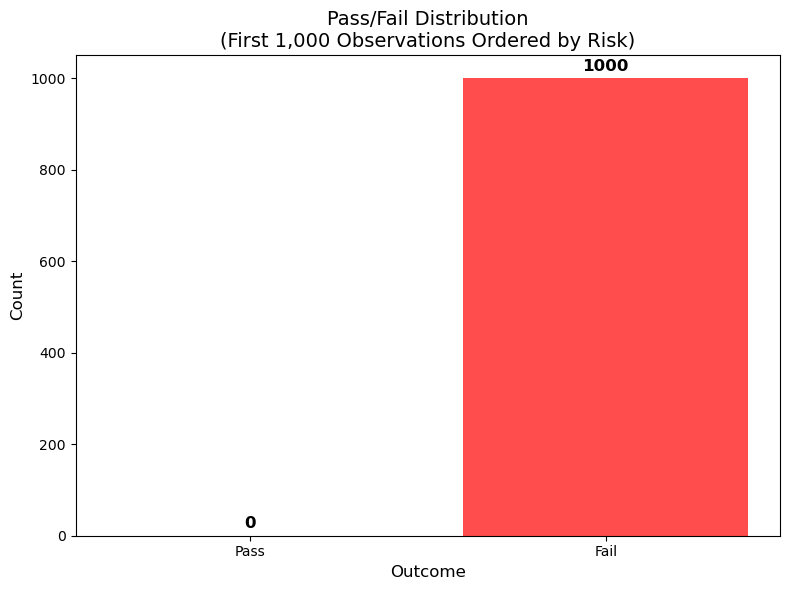

In [20]:
#
# 3. Plot your distribution of pass/fail among the first 1,000 observations in the dataset

# getting first 1,000 observations from the ordered dataset
first_1000 = audits_ordered.head(1000)

# counting passes and fails
pass_count = (first_1000['predicted_outcome'] == 0).sum()
fail_count = (first_1000['predicted_outcome'] == 1).sum()

# plotting
plt.figure(figsize=(8, 6))
plt.bar(['Pass', 'Fail'], [pass_count, fail_count], color=['green', 'red'], alpha=0.7)
plt.title('Pass/Fail Distribution\n(First 1,000 Observations Ordered by Risk)', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Outcome', fontsize=12)

# adding count labels on top of bars
plt.text(0, pass_count + 10, str(pass_count), ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.text(1, fail_count + 10, str(fail_count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


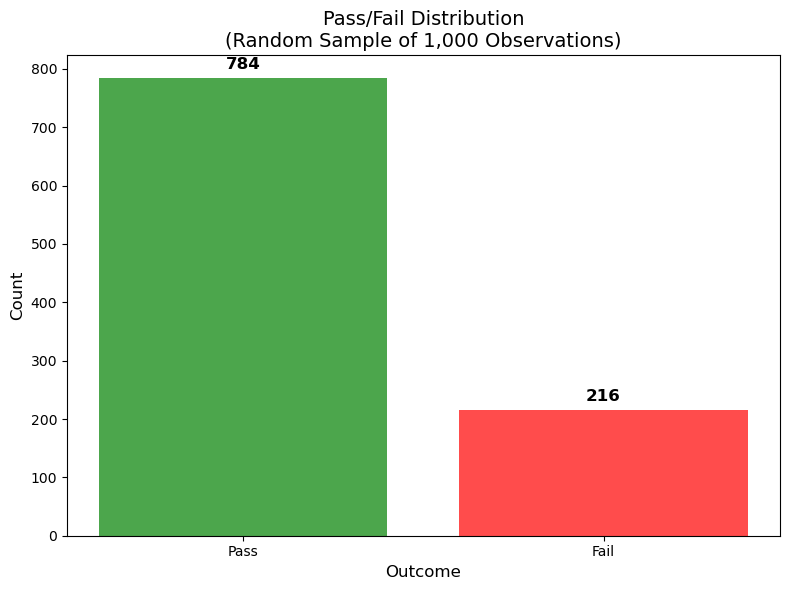

In [21]:
#
# 4. Simulate random audits on the full chicago_2011_to_2013.csv dataset by picking 1,000 observations at random

# simulating random audits by sampling 1,000 observations at random. 
random_audits = audits_df.sample(n=1000, random_state=42)

# counting passes and fails.
random_pass_count = (random_audits['predicted_outcome'] == 0).sum()
random_fail_count = (random_audits['predicted_outcome'] == 1).sum()

# plotting.
plt.figure(figsize=(8, 6))
plt.bar(['Pass', 'Fail'], [random_pass_count, random_fail_count], color=['green', 'red'], alpha=0.7)
plt.title('Pass/Fail Distribution\n(Random Sample of 1,000 Observations)', fontsize=14)
plt.ylabel('Count', fontsize=12)
plt.xlabel('Outcome', fontsize=12)

# adding count labels.
plt.text(0, random_pass_count + 10, str(random_pass_count), ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.text(1, random_fail_count + 10, str(random_fail_count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### Predict on 2014 inspection data

Use your favorite model to make predictions based on the features using the "Chicago Inspection 2014_updated.csv" file. Treat this as you would a test dataset. This means you will have to format the features (including removing some features and getting dummies) and the label (binarize and recode) in the same way you did the training data. (Remember the "Results" column is your label). You will then compare your predictions with the actual.

In [22]:
print(chicago_inspections_2014.columns.tolist())
print(chicago_inspections_2011_to_2013.columns.tolist())

['Inspection_ID', 'Inspection_Date', 'DBA_Name', 'AKA_Name', 'License', 'Facility_Type', 'Risk', 'Address', 'City', 'State', 'Zip', 'Inspection_Type', 'Latitude', 'Longitude', 'Location', 'Facility_Type_Clean', 'criticalCount', 'seriousCount', 'minorCount', 'pastFail', 'pastCritical', 'pastSerious', 'pastMinor', 'timeSinceLast', 'firstRecord', 'ID', 'LICENSE_ID', 'ACCOUNT_NUMBER', 'LEGAL_NAME', 'DOING_BUSINESS_AS_NAME', 'ADDRESS', 'CITY', 'STATE', 'ZIP_CODE', 'WARD', 'PRECINCT', 'WARD_PRECINCT', 'POLICE_DISTRICT', 'LICENSE_CODE', 'LICENSE_DESCRIPTION', 'BUSINESS_ACTIVITY_ID', 'BUSINESS_ACTIVITY', 'LICENSE_NUMBER', 'APPLICATION_TYPE', 'LICENSE_TERM_START_DATE', 'LICENSE_TERM_EXPIRATION_DATE', 'LICENSE_STATUS', 'LATITUDE', 'LONGITUDE', 'minDate', 'maxDate', 'ageAtInspection', 'consumption_on_premises_incidental_activity', 'tobacco', 'package_goods', 'outdoor_patio', 'public_place_of_amusement', 'limited_business_license', 'childrens_services_facility_license', 'tavern', 'regulated_busine

In [23]:
# data processing
# -----------

# drop column names related to geography, identification, and pass/fail flags that perfectly predict the outcome
# Note: Most of the original columns don't exist in the 2014 dataset, so we'll only drop what's there
columns_to_drop = ['WARD_PRECINCT', 'LICENSE_DESCRIPTION']

chicago_inspections_2014.drop(columns=columns_to_drop, inplace=True)

# Note: No index setting needed for 2014 dataset (Inspection_ID and DBA_Name don't exist)

# Note: No Inspection_Date column to convert

# drop any rows with missing values
chicago_inspections_2014 = chicago_inspections_2014.dropna()

# process target 
# -----------
y_test2014 = chicago_inspections_2014['Results']

# decide if you want to binarize the outcome variable 
# -----------
# comment out the following lines of code if you don't want to binarize the target variable
y_test2014 = y_test2014.replace({'Pass w/ Conditions': 'Pass'})
lb_style = LabelBinarizer()
y_test2014 = lb_style.fit_transform(y_test2014)
# recode 0s and 1s so 1s are "Fail"
y_test2014 = np.where(y_test2014 == 1, 0, 1)

# process features
# -----------
# create feature dataset
X_test2014 = chicago_inspections_2014.drop(columns=['Results', 'Facility_Type'])

# get dummies
X_test2014 = pd.get_dummies(X_test2014)

train_columns = best_rf_model.feature_names_in_
X_test2014 = X_test2014.reindex(columns=train_columns, fill_value=0)


In [24]:
# predict and compare 
# -----------

# making predictions on the 2014 test set.
y_pred_2014 = best_rf_model.predict(X_test2014)
y_pred_proba_2014 = best_rf_model.predict_proba(X_test2014)[:, 1] 

# comparing predictions with actual results.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

print("=== Random Forest Model Performance on 2014 Test Data ===")
print(f"Accuracy: {accuracy_score(y_test2014, y_pred_2014):.4f}")
print(f"Precision: {precision_score(y_test2014, y_pred_2014):.4f}")
print(f"Recall: {recall_score(y_test2014, y_pred_2014):.4f}")
print(f"F1-Score: {f1_score(y_test2014, y_pred_2014):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test2014, y_pred_proba_2014):.4f}")

print("\n=== Confusion Matrix ===")
print(confusion_matrix(y_test2014, y_pred_2014))

print("\n=== Classification Report ===")
print(classification_report(y_test2014, y_pred_2014))

# Optional: Compare with training performance
print("\n=== Comparison: Training vs Test Performance ===")
print(f"Best CV Score (Training): {grid_search.best_score_:.4f}")
print(f"Test Accuracy (2014): {accuracy_score(y_test2014, y_pred_2014):.4f}")


=== Random Forest Model Performance on 2014 Test Data ===
Accuracy: 0.9080
Precision: 0.7275
Recall: 0.8545
F1-Score: 0.7859
ROC-AUC Score: 0.9570

=== Confusion Matrix ===
[[2829  242]
 [ 110  646]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.96      0.92      0.94      3071
           1       0.73      0.85      0.79       756

    accuracy                           0.91      3827
   macro avg       0.85      0.89      0.86      3827
weighted avg       0.92      0.91      0.91      3827


=== Comparison: Training vs Test Performance ===
Best CV Score (Training): 0.9240
Test Accuracy (2014): 0.9080


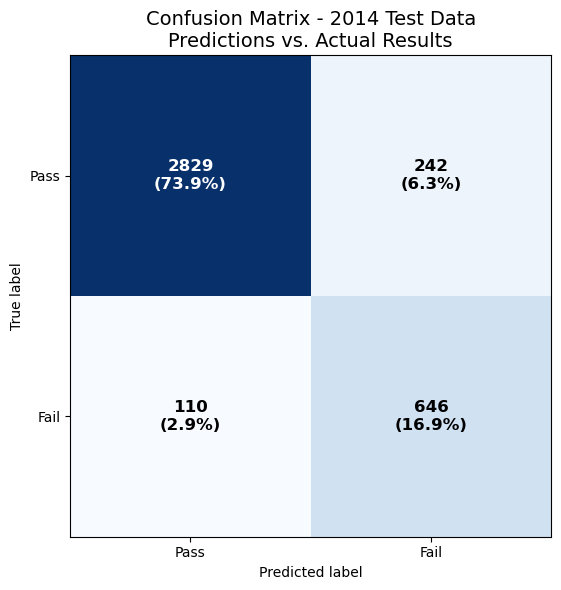

In [25]:
# evaluate
# -----------

# creating confusion matrix.
cm = confusion_matrix(y_test2014, y_pred_2014)

# calculating percentages.
cm_percent = cm.astype('float') / cm.sum() * 100

# creating labels with both counts and percentages.
labels = np.array([[f'{count}\n({percent:.1f}%)' 
                    for count, percent in zip(row_counts, row_percents)]
                   for row_counts, row_percents in zip(cm, cm_percent)])

# plotting.
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'Fail'])
disp.plot(cmap='Blues', ax=ax, colorbar=False, text_kw={'color': 'none'})

# adding count and percentage lables.
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, labels[i, j], 
                ha='center', va='center', 
                color='white' if cm[i, j] > cm.max() / 2 else 'black',
                fontsize=12, fontweight='bold')

plt.title('Confusion Matrix - 2014 Test Data\nPredictions vs. Actual Results', fontsize=14)
plt.tight_layout()
plt.show()


## 5. Discussion Questions

1. Why do we need metrics beyond accuracy when using machine learning in the social sciences and public policy?


**YOUR ANSWER HERE**...

2. Imagine that establishments learned about the algorithm being used to determine who gets audited and they started adjusting their behavior (and changing certain key features about themselves that were important for the prediction) to avoid detection. How could policymakers address this interplay between algorithmic decisionmaking and real world behavior?

**YOUR ANSWER HERE**...